# 01 · Türev, Kısmi Türev ve Gradyan Vektörü
**Calculus Lab** — Faz 1'in Son Ayağının İlk Notebook'u

---
> **Bu notebook'ta ne öğreneceğiz?**  
> `probability-lab` 08'de (MLE=OLS) "log-likelihood'u maksimize etmek için türev al,
> sıfıra eşitle" demiştik ama türev almanın kendisine hiç girmemiştik. `linear-algebra-lab`
> 05'te Hessian'ın (ikinci türevlerin matrisi) pozitif tanımlılığından bahsetmiştik ama
> türevin ne olduğunu varsaymıştık. Bu notebook, o varsayılan bilgiyi sıfırdan kuruyor:
> türev nedir, kısmi türev nedir, ve bunların hepsini tek bir vektörde toplayan **gradyan**
> nedir? Bu üçü, tüm makine öğrenmesi model eğitiminin (gradient descent, backpropagation)
> matematiksel temeli.

**Önkoşul:** Yok — bu, `calculus-lab`'ın ilk notebook'u  
**Veri:**  
- `time_series_covid_19_confirmed.csv` — 276 ülke/bölge, 2020-01-22'den 2021-05-29'a kadar günlük kümülatif vaka sayısı  
- Sentetik 2D/3D yüzeyler (`sympy`/`numpy`) — gradyan vektörü görselleştirmesi için  
**Araçlar:** Python (`sympy`, `numpy`, `matplotlib`)

---
## 1 · Türev Nedir? "Anlık Değişim Hızı"

Bir fonksiyonun türevi, o fonksiyonun bir noktadaki **anlık değişim hızını** (eğimini)
gösterir. Somut bir örnek: bir arabanın konumunu zamana göre gösteren bir fonksiyon
$x(t)$ varsa, türevi $x'(t)$ **hız**dır — "konum ne kadar hızlı değişiyor" sorusunun cevabı.

**Formal tanım:**
$$f'(x) = \lim_{h\to 0} \frac{f(x+h)-f(x)}{h}$$

Bu formül, aslında çok basit bir fikri matematiksel dille yazıyor: "$x$ noktasından ÇOK KÜÇÜK
bir adım ($h$) attığında, fonksiyon ne kadar değişiyor, bunu adımın büyüklüğüne oranla?"
$h$'yi sıfıra yaklaştırdıkça, bu oran fonksiyonun o noktadaki "anlık eğimine" yakınsıyor.

---
## 2 · Kısmi Türev: Çok Değişkenli Fonksiyonlarda "Bir Değişkeni İzole Etmek"

Gerçek dünyadaki çoğu fonksiyon tek değişkenli değil — örneğin bir evin fiyatı hem metrekareye
hem yaşına bağlı: $f(\text{metrekare}, \text{yaş})$. **Kısmi türev**, bu tür fonksiyonlarda
"SADECE bir değişkeni değiştirip DİĞERLERİNİ SABİT tutarsam ne olur" sorusunu soruyor:

$$\frac{\partial f}{\partial x} = \text{"$y$'yi SABİT tutarak, $f$'nin $x$'e göre türevi"}$$

**Somut örnek:** $f(x,y) = x^2y + 3y$ fonksiyonu için:
- $\frac{\partial f}{\partial x} = 2xy$ ($y$'yi sabit sayı gibi düşünüp SADECE $x$'e göre türet)
- $\frac{\partial f}{\partial y} = x^2 + 3$ ($x$'i sabit sayı gibi düşünüp SADECE $y$'ye göre türet)

Hepsi bu kadar — kısmi türev, "diğer değişkenleri sabit kabul et" kuralı dışında normal
türev almadan farksız.

---
## 3 · Gradyan Vektörü: Tüm Kısmi Türevleri Bir Araya Toplamak

Bir fonksiyonun TÜM kısmi türevlerini tek bir vektörde topladığında, **gradyan vektörünü**
($\nabla f$) elde edersin:

$$\nabla f = \begin{bmatrix}\dfrac{\partial f}{\partial x}\\[6pt]\dfrac{\partial f}{\partial y}\end{bmatrix}$$

**Neden önemli? Gradyanın EN kritik özelliği:** Gradyan vektörü, fonksiyonun **en dik ARTIŞ**
yönünü gösterir. Bir dağın herhangi bir noktasında durduğunu düşün — gradyan, "en dik yokuş
yukarı" yönünü işaret eden bir pusula gibi. Bu yüzden `calculus-lab` 04'te göreceğimiz
gradient descent algoritması, gradyanın TERSİ yönünde ilerleyerek (en dik İNİŞ yönünde)
bir fonksiyonun minimumunu arıyor.

---
## 4 · Sayısal Türev vs Analitik Türev

İki farklı şekilde türev "bulabilirsin":

- **Analitik (kapalı-form) türev:** Türev kurallarını (çarpım kuralı, zincir kuralı, vb.)
  ELLE uygulayıp KESİN bir formül elde etmek. Örnek: $f(x)=x^2$'nin türevi KESİN olarak
  $f'(x)=2x$'tir.
- **Sayısal (numerical) türev:** Formal tanımdaki $h\to 0$ limitini gerçekte alamayacağın
  için, ÇOK KÜÇÜK ama sıfır olmayan bir $h$ kullanıp YAKLAŞIK bir değer hesaplamak:
  $$f'(x) \approx \frac{f(x+h)-f(x)}{h} \quad (\text{"sonlu farklar" yöntemi})$$

**Ne zaman hangisi?** Fonksiyonun formülünü biliyorsan (örn. $x^2$), analitik türev her
zaman tercih edilir — kesin ve hızlıdır. Ama COVID vaka sayısı gibi **sadece verisi olan**
(hiçbir "formülü" olmayan) bir şeyin "türevini" almak istediğinde, SADECE sayısal türev
kullanabilirsin — bu notebook'un can alıcı noktalarından biri.

---
# 🐍 Python Uygulaması

5 adımda ilerleyeceğiz:
1. **Temel Türev Kuralları** — `sympy` ile sembolik türev alma
2. **Sayısal Türev: Sonlu Farklar** — $h$ küçüldükçe analitik türeve yakınsama
3. **Gerçek Veride Türev: COVID-19 Vaka Artış Hızı** — Birinci ve ikinci türev
4. **Çok Değişkenli Gradyan Vektörü** — 3D yüzeyde "en dik artış" yönünü görselleştirme
5. **Gradyanın Fonksiyon Konturlarına Her Zaman Dik Olduğunu Kanıtlama**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 7)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 📐 Python 1 — Temel Türev Kuralları: `sympy` ile Sembolik Türev

**Ne yapıyoruz?**  
Bölüm 2'deki $f(x,y)=x^2y+3y$ örneğini `sympy` ile doğruluyoruz, ayrıca birkaç bilinen
fonksiyonun (polinom, üstel, logaritmik) türevini alıp KURALLARI hatırlıyoruz.

In [2]:
x, y = sp.symbols('x y')

# Bolum 2'deki ornegi dogrulayalim
f = x**2 * y + 3*y
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)

print(f"f(x,y) = {f}")
print(f"∂f/∂x = {df_dx}  (elle: 2xy)")
print(f"∂f/∂y = {df_dy}  (elle: x²+3)")

# Bilinen fonksiyonlarin turevleri - kurallari hatirlayalim
print("\n=== Temel Türev Kuralları ===")
fonksiyonlar = {
    'x^n (üs kuralı)': x**5,
    'e^x (üstel)': sp.exp(x),
    'ln(x) (logaritmik)': sp.ln(x),
    'sin(x)': sp.sin(x),
    '1/(1+e^-x) (sigmoid - ML\'de çok kullanılır)': 1 / (1 + sp.exp(-x)),
}
for isim, fonk in fonksiyonlar.items():
    turev = sp.diff(fonk, x) # Türev al
    print(f"d/dx[{isim}] = {sp.simplify(turev)}")

f(x,y) = x**2*y + 3*y
∂f/∂x = 2*x*y  (elle: 2xy)
∂f/∂y = x**2 + 3  (elle: x²+3)

=== Temel Türev Kuralları ===
d/dx[x^n (üs kuralı)] = 5*x**4
d/dx[e^x (üstel)] = exp(x)
d/dx[ln(x) (logaritmik)] = 1/x
d/dx[sin(x)] = cos(x)
d/dx[1/(1+e^-x) (sigmoid - ML'de çok kullanılır)] = 1/(4*cosh(x/2)**2)


---
### 🔢 Python 2 — Sayısal Türev: Sonlu Farklar ile Yakınsama

**Ne yapıyoruz?**  
$f(x)=x^3$ fonksiyonunun $x=2$ noktasındaki türevini hem analitik ($f'(x)=3x^2$, yani
$f'(2)=12$) hem sayısal (sonlu farklar) olarak hesaplayıp, $h$ küçüldükçe sayısal
sonucun analitik sonuca nasıl yakınsadığını göreceğiz.

Analitik türev, f'(2) = 12

         h |   Sayısal Türev |   Analitikten Fark
--------------------------------------------------
         1 |       19.000000 |           7.000000
       0.1 |       12.610000 |           0.610000
      0.01 |       12.060100 |           0.060100
     0.001 |       12.006001 |           0.006001
    0.0001 |       12.000600 |           0.000600
     1e-05 |       12.000060 |           0.000060


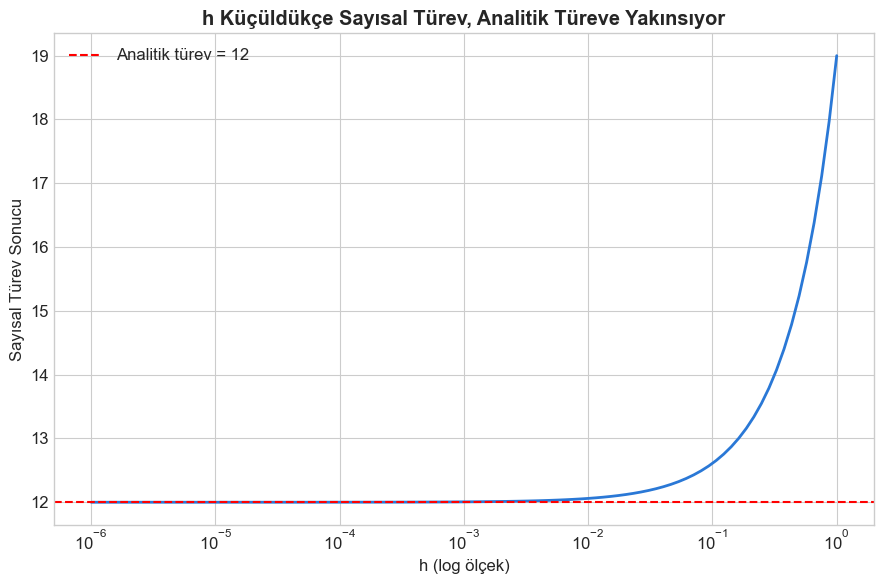


YORUM: h çok büyükken (h=1) sayısal türev analitikten belirgin şekilde uzak.
h küçüldükçe fark hızla sıfıra yaklaşıyor - bu, formal tanımdaki 'h→0' limitinin
pratikte nasıl çalıştığının somut kanıtı.


In [3]:
def f(x):
    return x**3

def sayisal_turev(f, x, h):
    return (f(x + h) - f(x)) / h

x0 = 2
analitik_turev = 3 * x0**2  # f'(x)=3x^2 formulunden
print(f"Analitik türev, f'(2) = {analitik_turev}")

h_degerleri = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
print(f"\n{'h':>10} | {'Sayısal Türev':>15} | {'Analitikten Fark':>18}")
print("-" * 50)
for h in h_degerleri:
    sayisal = sayisal_turev(f, x0, h)
    fark = abs(sayisal - analitik_turev)
    print(f"{h:>10} | {sayisal:>15.6f} | {fark:>18.6f}")

fig, ax = plt.subplots(figsize=(9, 6))
h_araligi = np.logspace(-6, 0, 100)
sayisal_sonuclar = [sayisal_turev(f, x0, h) for h in h_araligi]
ax.plot(h_araligi, sayisal_sonuclar, color='#2a78d6', linewidth=2)
ax.axhline(analitik_turev, color='red', linestyle='--', label=f"Analitik türev = {analitik_turev}")
ax.set_xscale('log')
ax.set_xlabel('h (log ölçek)')
ax.set_ylabel("Sayısal Türev Sonucu")
ax.set_title("h Küçüldükçe Sayısal Türev, Analitik Türeve Yakınsıyor", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: h çok büyükken (h=1) sayısal türev analitikten belirgin şekilde uzak.")
print("h küçüldükçe fark hızla sıfıra yaklaşıyor - bu, formal tanımdaki 'h→0' limitinin")
print("pratikte nasıl çalıştığının somut kanıtı.")

---
### 🦠 Python 3 — Gerçek Veride Türev: COVID-19 Vaka Artış Hızı

**Ne yapıyoruz?**  
Elimizde SADECE veri var (kümülatif vaka sayısı, günlük) — hiçbir "formül" yok, bu yüzden
Bölüm 4'teki **sayısal türev** tekniğini kullanmak ZORUNDAYIZ. Türkiye'nin kümülatif vaka
eğrisinin **birinci türevini** (günlük yeni vaka = "hız") ve **ikinci türevini**
(ivmelenme — salgının hızlanıp hızlanmadığı) hesaplayacağız.

**Önemli not:** Burada $h$ sabit — veri günlük olduğu için en küçük mümkün adımımız
"1 gün". Bu yüzden formülümüz basitçe $f'(t) \approx f(t) - f(t-1)$ oluyor (ardışık
günler arası fark) — sonlu farklar yönteminin gerçek veriye uygulanmış hali.

Veri: 276 ülke/bölge, 494 günlük ölçüm

İlk gün (2020-01-22): 0 kümülatif vaka
Son gün (2021-05-29): 5235978 kümülatif vaka


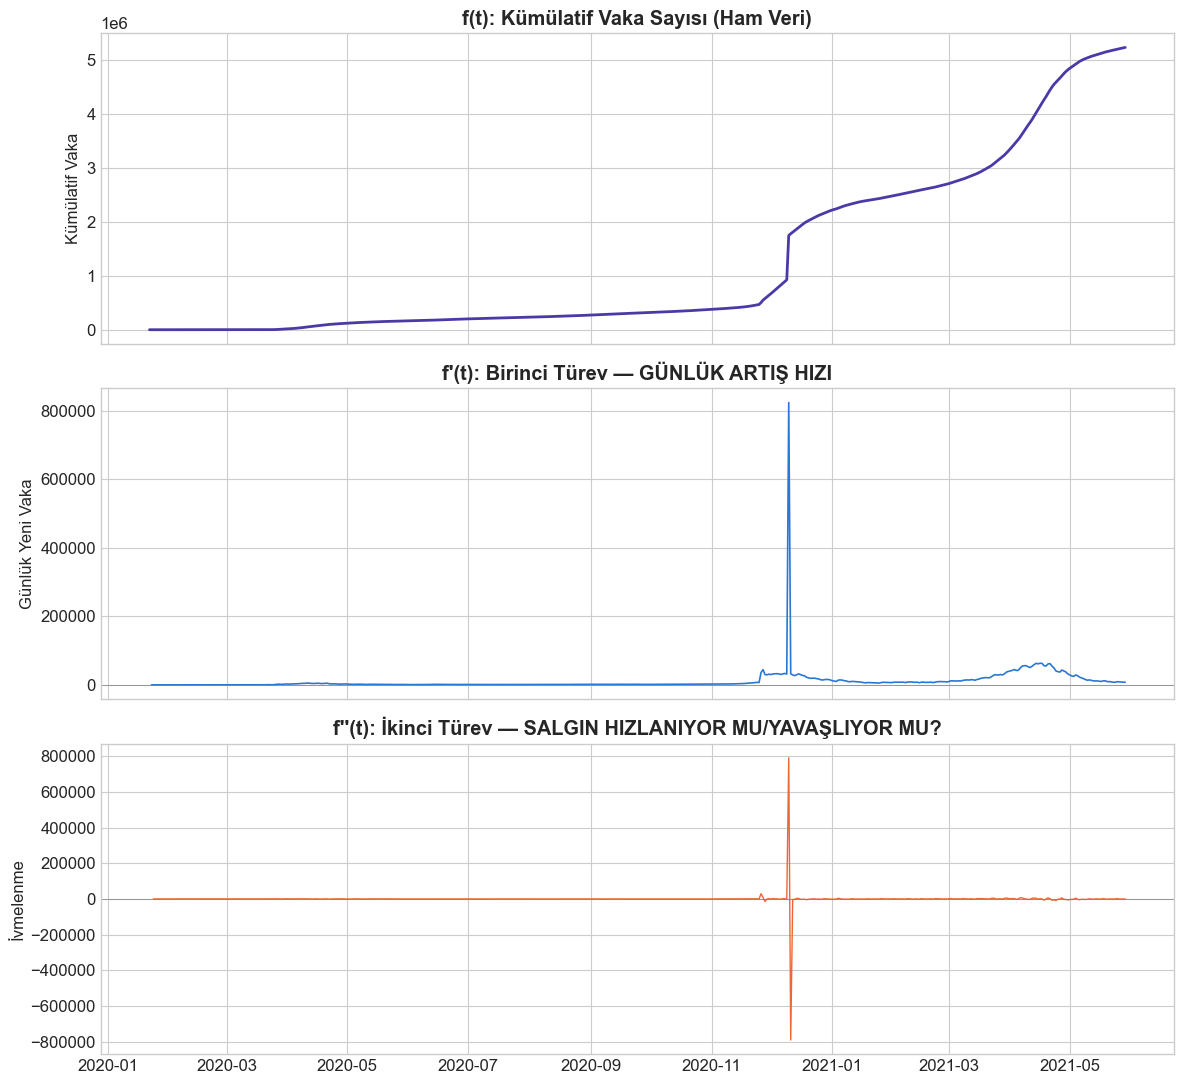


YORUM: Üstteki grafik hep ARTAN (kümülatif sayı asla azalmaz - mantıklı).
Ortadaki grafik (birinci türev) dalgalanıyor - bazı günler daha çok yeni vaka,
bazı günler daha az. Alttaki grafik (ikinci türev) SIFIRIN ÜSTÜNDEYSE salgın
HIZLANIYOR (her gün bir önceki günden daha çok yeni vaka), SIFIRIN ALTINDAYSA
YAVAŞLIYOR demektir - dalga tepe noktalarının etrafında ikinci türevin işaret
değiştirdiğine dikkat et (tıpkı bir fonksiyonun maksimumunda türevin sıfır olması gibi).


In [4]:
covid = pd.read_csv('data/time_series_covid_19_confirmed.csv')
print(f"Veri: {covid.shape[0]} ülke/bölge, {covid.shape[1]-4} günlük ölçüm")

# Turkiye satirini sec, ulke bazinda tek satir (Province/State bos)
turkiye = covid[covid['Country/Region'] == 'Turkey'].iloc[0]
tarih_kolonlari = covid.columns[4:]  # ilk 4 kolon: Province/State, Country/Region, Lat, Long
kumulatif_vaka = turkiye[tarih_kolonlari].astype(float).values
tarihler = pd.to_datetime(tarih_kolonlari, format='%m/%d/%y')

print(f"\nİlk gün ({tarihler[0].date()}): {kumulatif_vaka[0]:.0f} kümülatif vaka")
print(f"Son gün ({tarihler[-1].date()}): {kumulatif_vaka[-1]:.0f} kümülatif vaka")

# BIRINCI TUREV: gunluk yeni vaka = f(t) - f(t-1), h=1 gun sabit
gunluk_yeni_vaka = np.diff(kumulatif_vaka)  # np.diff otomatik olarak ardisik farklari alir

# IKINCI TUREV: gunluk yeni vaka SAYISININ KENDISININ degisim hizi (ivmelenme)
ivmelenme = np.diff(gunluk_yeni_vaka)

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

axes[0].plot(tarihler, kumulatif_vaka, color='#4a3aa7', linewidth=2)
axes[0].set_ylabel('Kümülatif Vaka')
axes[0].set_title('f(t): Kümülatif Vaka Sayısı (Ham Veri)', fontweight='bold')

axes[1].plot(tarihler[1:], gunluk_yeni_vaka, color='#2a78d6', linewidth=1.2)
axes[1].set_ylabel('Günlük Yeni Vaka')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].set_title("f'(t): Birinci Türev — GÜNLÜK ARTIŞ HIZI", fontweight='bold')

axes[2].plot(tarihler[2:], ivmelenme, color='#eb6834', linewidth=1)
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].set_ylabel('İvmelenme')
axes[2].set_title("f''(t): İkinci Türev — SALGIN HIZLANIYOR MU/YAVAŞLIYOR MU?", fontweight='bold')

plt.tight_layout()
plt.show()

print("\nYORUM: Üstteki grafik hep ARTAN (kümülatif sayı asla azalmaz - mantıklı).")
print("Ortadaki grafik (birinci türev) dalgalanıyor - bazı günler daha çok yeni vaka,")
print("bazı günler daha az. Alttaki grafik (ikinci türev) SIFIRIN ÜSTÜNDEYSE salgın")
print("HIZLANIYOR (her gün bir önceki günden daha çok yeni vaka), SIFIRIN ALTINDAYSA")
print("YAVAŞLIYOR demektir - dalga tepe noktalarının etrafında ikinci türevin işaret")
print("değiştirdiğine dikkat et (tıpkı bir fonksiyonun maksimumunda türevin sıfır olması gibi).")

---
### 🏔️ Python 4 — Çok Değişkenli Fonksiyonda Gradyan Vektörü: "En Dik Artış Yönü"

**Ne yapıyoruz?**  
$f(x,y)=x^2+y^2$ (bir "çanak/kase" yüzeyi — `linear-algebra-lab` 05'teki konveks
örneğimizi hatırla) üzerinde birkaç farklı noktada gradyan vektörünü hesaplayıp,
**gerçekten en dik artış yönünü gösterdiğini** görsel olarak kanıtlayacağız.

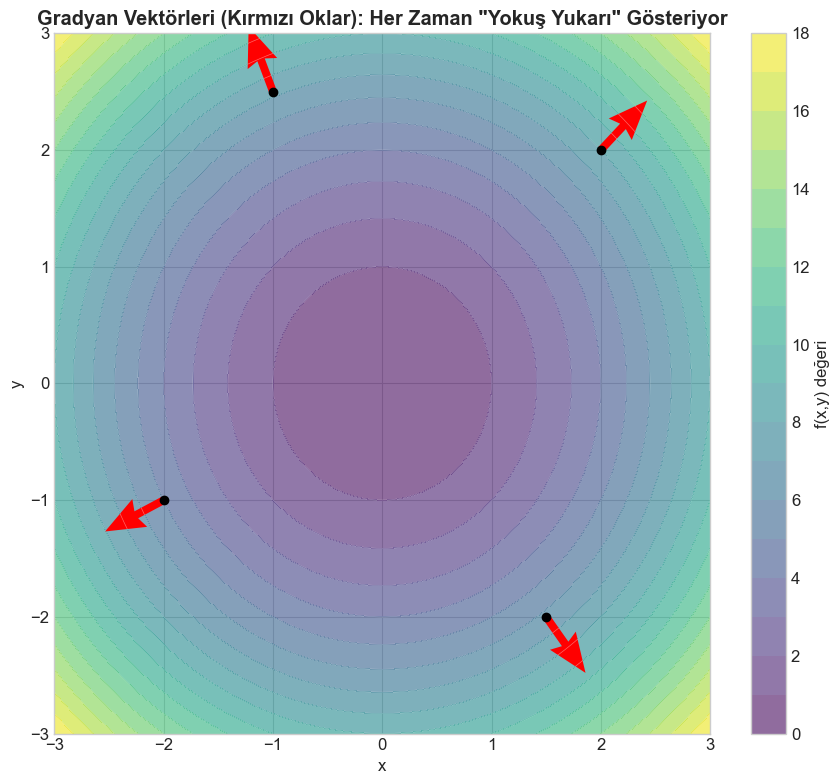

YORUM: Her kırmızı ok, bulunduğu noktadan MERKEZE UZAKLAŞAN yönü gösteriyor -
çünkü bu yüzeyde f(x,y) MERKEZDEN uzaklaştıkça artıyor (bir çanağın kenarına doğru
tırmanmak gibi). Bu, gradyanın 'en dik ARTIŞ yönü' tanımının görsel kanıtı.


In [6]:
def f_yuzey(x, y):
    return x**2 + y**2

def gradyan_f(x, y):
    # Bolum 2'deki kisimi turev kurallarindan: df/dx=2x, df/dy=2y
    return np.array([2*x, 2*y])

x_grid = np.linspace(-3, 3, 100)
y_grid = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_grid, y_grid) # meshgrid ile 2D grid olusturduk
Z = f_yuzey(X, Y)

test_noktalari = [(-2, -1), (1.5, -2), (2, 2), (-1, 2.5)]

fig, ax = plt.subplots(figsize=(9, 8))
kontur = ax.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
ax.contour(X, Y, Z, levels=20, colors='white', linewidths=0.5, alpha=0.4)
plt.colorbar(kontur, label='f(x,y) değeri')

for (px, py) in test_noktalari:
    grad = gradyan_f(px, py)
    grad_normalize = grad / np.linalg.norm(grad) * 0.6  # gorsellestirme icin sabit uzunluk
    ax.quiver(px, py, *grad_normalize, angles='xy', scale_units='xy', scale=1,
              color='red', width=0.012, headwidth=4)
    ax.plot(px, py, 'ko', markersize=6)

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Gradyan Vektörleri (Kırmızı Oklar): Her Zaman "Yokuş Yukarı" Gösteriyor', fontweight='bold')
plt.tight_layout()
plt.show()

print("YORUM: Her kırmızı ok, bulunduğu noktadan MERKEZE UZAKLAŞAN yönü gösteriyor -")
print("çünkü bu yüzeyde f(x,y) MERKEZDEN uzaklaştıkça artıyor (bir çanağın kenarına doğru")
print("tırmanmak gibi). Bu, gradyanın 'en dik ARTIŞ yönü' tanımının görsel kanıtı.")

---
### 📐 Python 5 — Gradyan, Kontur Çizgilerine Her Zaman DİKTİR

**Ne yapıyoruz?**  
Az bilinen ama çok kullanışlı bir gerçeği kanıtlıyoruz: gradyan vektörü, fonksiyonun
**eş-değer çizgilerine (kontur çizgilerine) HER ZAMAN dik açıyla** duruyor. Bunu bir
noktada hem gradyanı hem o noktadaki kontur çizgisinin teğetini çizerek göstereceğiz.

Gradyan vektörü: [ 3. -4.]
Teğet (kontura paralel) yön: [4. 3.]
İç çarpımları (linear-algebra-lab 01'deki formül): -0.0000000000
Sıfıra eşit mi (yani DİK mi)? EVET ✓


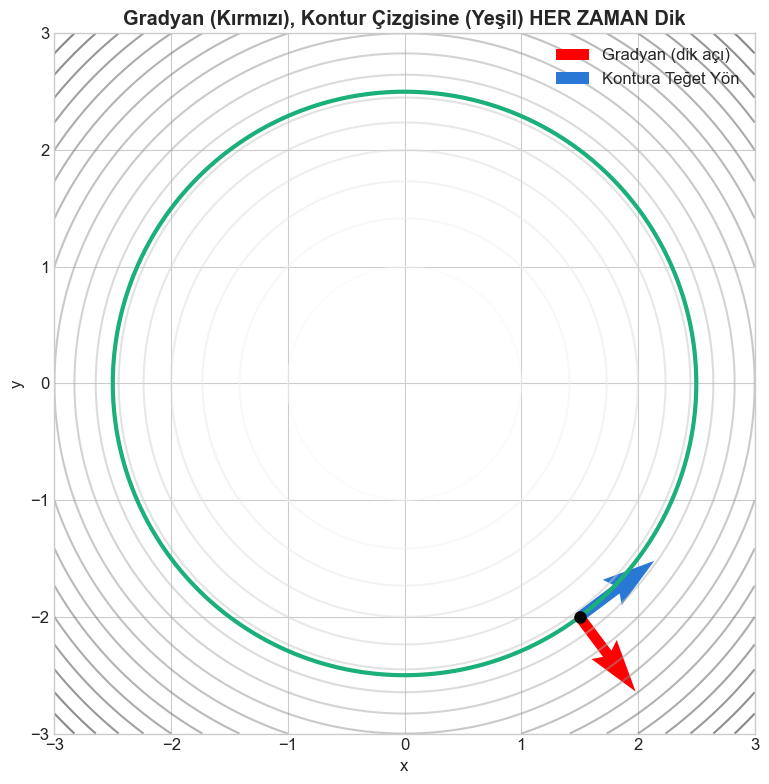


YORUM: Kırmızı ok (gradyan) ile mavi ok (kontura teğet yön) arasında TAM 90°
açı var - bu tesadüf değil, HER fonksiyonda, HER noktada geçerli genel bir kural.
Sezgisi: kontur çizgisi 'f'nin DEĞİŞMEDİĞİ' yön, gradyan ise 'f'nin EN HIZLI
değiştiği' yön - bu ikisi mantıksal olarak birbirine dik olmak ZORUNDA.


In [7]:
px, py = 1.5, -2  # test noktalarindan biri
grad = gradyan_f(px, py)

# Bu noktadaki kontur cizgisine TEGET olan yonu bulalim: gradyana DIK olan yon
# (bir vektore dik olan yon, x ve y bileşenlerini yer değiştirip birinin işaretini ters çevirerek bulunur)
teget_yonu = np.array([-grad[1], grad[0]])
teget_normalize = teget_yonu / np.linalg.norm(teget_yonu)
grad_normalize = grad / np.linalg.norm(grad)

# Iki vektorun ic carpimi (01'deki formul) TAM SIFIR olmali, dik olduklarinin kaniti
ic_carpim = np.dot(grad_normalize, teget_normalize)
print(f"Gradyan vektörü: {np.round(grad, 3)}")
print(f"Teğet (kontura paralel) yön: {np.round(teget_yonu, 3)}")
print(f"İç çarpımları (linear-algebra-lab 01'deki formül): {ic_carpim:.10f}")
print(f"Sıfıra eşit mi (yani DİK mi)? {'EVET ✓' if abs(ic_carpim) < 1e-10 else 'HAYIR'}")

fig, ax = plt.subplots(figsize=(9, 8))
ax.contour(X, Y, Z, levels=20, cmap='Greys', alpha=0.5)
belirli_kontur_degeri = f_yuzey(px, py)
ax.contour(X, Y, Z, levels=[belirli_kontur_degeri], colors='#1baf7a', linewidths=3)

ax.quiver(px, py, *(grad_normalize*0.8), angles='xy', scale_units='xy', scale=1,
          color='red', width=0.015, label='Gradyan (dik açı)')
ax.quiver(px, py, *(teget_normalize*0.8), angles='xy', scale_units='xy', scale=1,
          color='#2a78d6', width=0.015, label='Kontura Teğet Yön')
ax.plot(px, py, 'ko', markersize=8)

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Gradyan (Kırmızı), Kontur Çizgisine (Yeşil) HER ZAMAN Dik', fontweight='bold')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("\nYORUM: Kırmızı ok (gradyan) ile mavi ok (kontura teğet yön) arasında TAM 90°")
print("açı var - bu tesadüf değil, HER fonksiyonda, HER noktada geçerli genel bir kural.")
print("Sezgisi: kontur çizgisi 'f'nin DEĞİŞMEDİĞİ' yön, gradyan ise 'f'nin EN HIZLI")
print("değiştiği' yön - bu ikisi mantıksal olarak birbirine dik olmak ZORUNDA.")

---
## ✏️ Egzersizler

---

### **E1.**
$f(x,y) = 3x^2y^3 - 2x + 5y$ için $\frac{\partial f}{\partial x}$ ve
$\frac{\partial f}{\partial y}$'yi ELLE hesapla, `sympy` ile doğrula.

In [8]:
print("\n ==== Egzersiz 1: Formül ile Kısmi Türev Hesabı")

x, y = sp.symbols('x y')

f_yeni = 3*x**2*y**3 - 2*x + 5*y
df_dx = sp.diff(f_yeni, x)
df_dy = sp.diff(f_yeni, y)
print(f"f(x,y) = {f_yeni}")
print(f"∂f/∂x = {df_dx}  (elle: 6xy³ - 2)")
print(f"∂f/∂y = {df_dy}  (elle: 9x²y² + 5)")


 ==== Egzersiz 1: Formül ile Kısmi Türev Hesabı
f(x,y) = 3*x**2*y**3 - 2*x + 5*y
∂f/∂x = 6*x*y**3 - 2  (elle: 6xy³ - 2)
∂f/∂y = 9*x**2*y**2 + 5  (elle: 9x²y² + 5)


---

### **E2.**
Python 2'deki sonlu farklar yöntemini $f(x)=\sin(x)$ için $x=\pi/4$ noktasında
tekrarla (analitik türev: $f'(x)=\cos(x)$). Aynı yakınsama grafiğini çiz.


 ==== Egzersiz 2: Sonlu Farklar Türevi Hesaplama ====
Analitik türev, f'(π/4) = 0.707107

         h |   Sayısal Türev |   Analitikten Fark
--------------------------------------------------
         1 |        0.269954 |           0.437152
       0.1 |        0.670603 |           0.036504
      0.01 |        0.703559 |           0.003547
     0.001 |        0.706753 |           0.000354
    0.0001 |        0.707071 |           0.000035
     1e-05 |        0.707103 |           0.000004


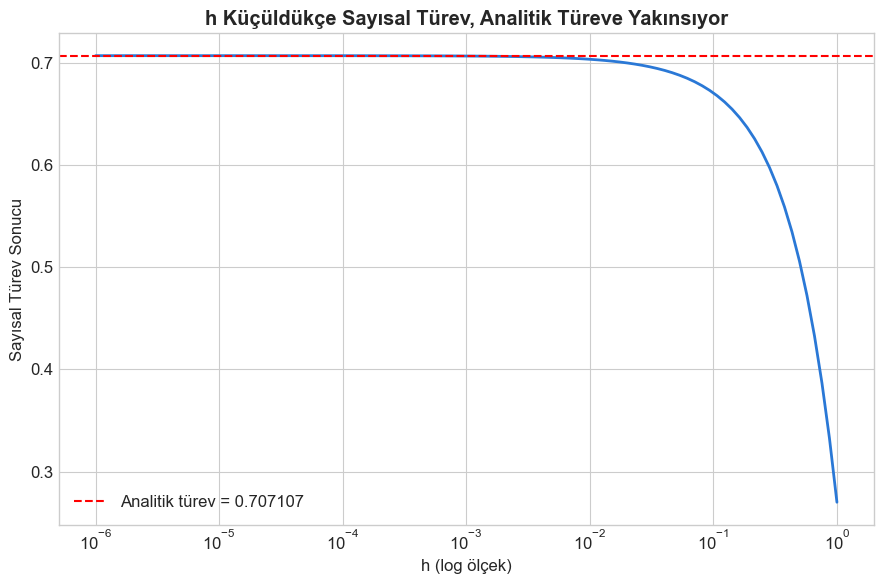

In [10]:
print("\n ==== Egzersiz 2: Sonlu Farklar Türevi Hesaplama ====")

def sayisal_turev(f, x, h):
    return (f(x + h) - f(x)) / h

sinus = np.sin
x0 = np.pi / 4  # 45 derece
analitik_turev = np.cos(x0)  # f'(x)=cos(x) formulunden
print(f"Analitik türev, f'(π/4) = {analitik_turev:.6f}")

h_degerleri = [1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
print(f"\n{'h':>10} | {'Sayısal Türev':>15} | {'Analitikten Fark':>18}")
print("-" * 50)
for h in h_degerleri:
    sayisal = sayisal_turev(sinus, x0, h)
    fark = abs(sayisal - analitik_turev)
    print(f"{h:>10} | {sayisal:>15.6f} | {fark:>18.6f}")

fig, ax = plt.subplots(figsize=(9, 6))
h_araligi = np.logspace(-6, 0, 100)
sayisal_sonuclar = [sayisal_turev(sinus, x0, h) for h in h_araligi]
ax.plot(h_araligi, sayisal_sonuclar, color='#2a78d6', linewidth=2)
ax.axhline(analitik_turev, color='red', linestyle='--', label=f"Analitik türev = {analitik_turev:.6f}")
ax.set_xscale('log')
ax.set_xlabel('h (log ölçek)')
ax.set_ylabel("Sayısal Türev Sonucu")
ax.set_title("h Küçüldükçe Sayısal Türev, Analitik Türeve Yakınsıyor", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---

### **E3.** 
COVID verisinde başka bir ülke seç (kendi ilgini çeken), aynı üçlü grafiği
(kümülatif/birinci türev/ikinci türev) çiz. İkinci türevin sıfırı kestiği noktaların,
üstteki kümülatif eğrideki "dönüm noktalarına" (eğrinin S-şeklinden düzleşmeye geçtiği
yerlere) denk geldiğini gözlemle.



 ==== Egzersiz 3: Bulgaristan Covid-19 Verisi Türev Hesabı ====

İlk gün (2020-01-22): 0 kümülatif vaka
Son gün (2021-05-29): 418221 kümülatif vaka


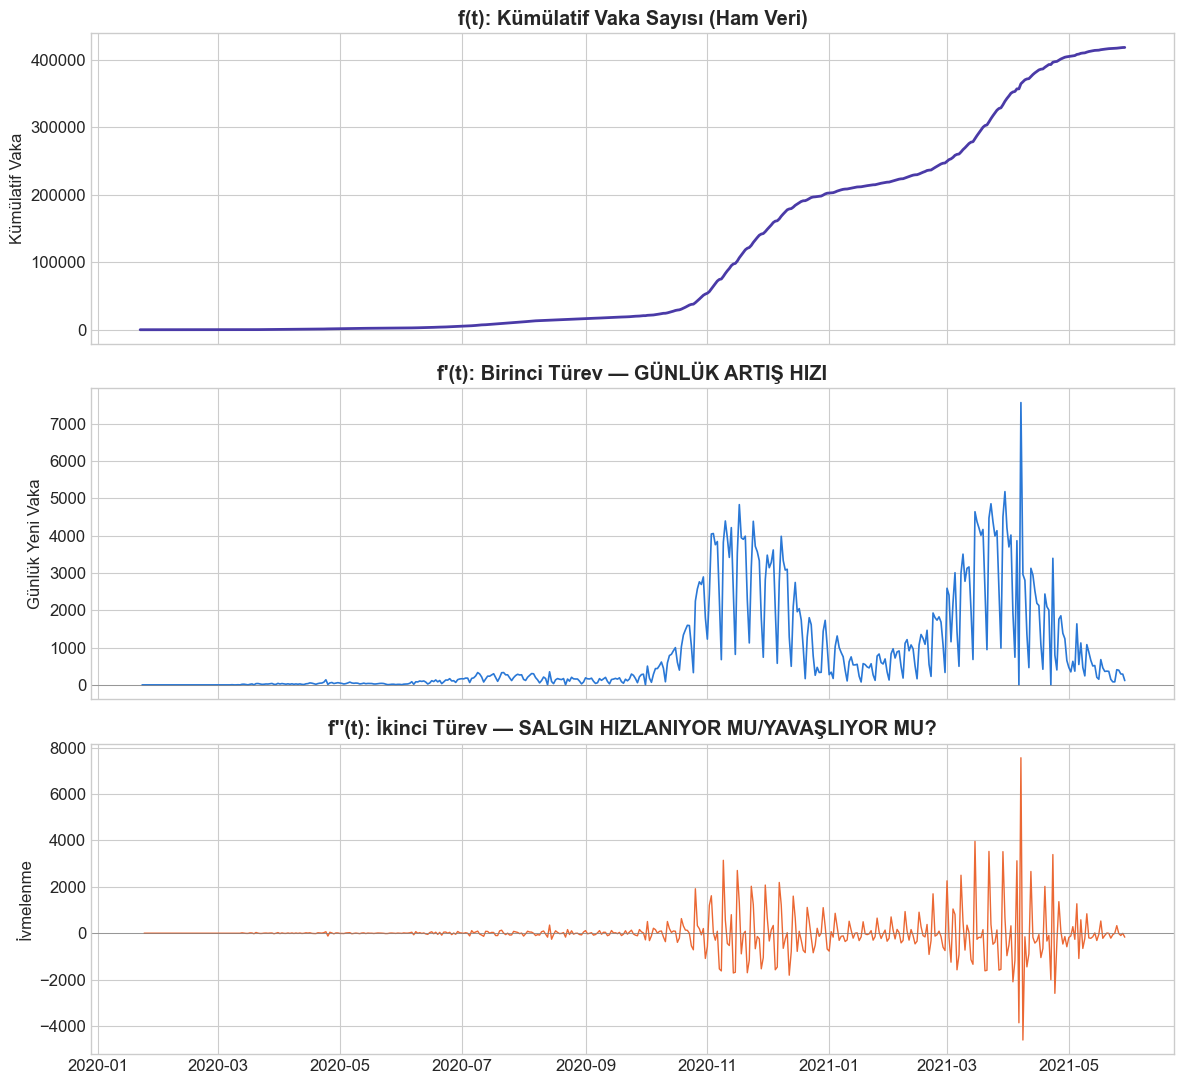

In [12]:
print("\n ==== Egzersiz 3: Bulgaristan Covid-19 Verisi Türev Hesabı ====")

bulgaria = covid[covid['Country/Region'] == 'Bulgaria'].iloc[0]
tarih_kolonlari = covid.columns[4:]  # ilk 4 kolon: Province/State, Country/Region, Lat, Long
kumulatif_vaka_bulgaria = bulgaria[tarih_kolonlari].astype(float).values
tarihler_bulgaria = pd.to_datetime(tarih_kolonlari, format='%m/%d/%y')

print(f"\nİlk gün ({tarihler_bulgaria[0].date()}): {kumulatif_vaka_bulgaria[0]:.0f} kümülatif vaka")
print(f"Son gün ({tarihler_bulgaria[-1].date()}): {kumulatif_vaka_bulgaria[-1]:.0f} kümülatif vaka")

gunluk_yeni_vaka_bulgaria = np.diff(kumulatif_vaka_bulgaria) 
# Türevin sonucunu bilmediğimiz için, bu satırda bir hata oluştu. `np.diff` fonksiyonu, bir dizinin ardışık elemanlarının farkını alır ve bu nedenle türev hesaplamasında kullanılabilir. Ancak, türev hesaplaması için daha fazla bilgiye ihtiyaç vardır.

ivmelenme = np.diff(gunluk_yeni_vaka_bulgaria)
# İkinci türevini alarakta günlük yeni vaka sayısının değişim hızını hesaplayabiliriz. Bu, salgının hızlanıp hızlanmadığını anlamamıza yardımcı olur.

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

axes[0].plot(tarihler_bulgaria, kumulatif_vaka_bulgaria, color='#4a3aa7', linewidth=2)
axes[0].set_ylabel('Kümülatif Vaka')
axes[0].set_title('f(t): Kümülatif Vaka Sayısı (Ham Veri)', fontweight='bold')

axes[1].plot(tarihler_bulgaria[1:], gunluk_yeni_vaka_bulgaria, color='#2a78d6', linewidth=1.2)
axes[1].set_ylabel('Günlük Yeni Vaka')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].set_title("f'(t): Birinci Türev — GÜNLÜK ARTIŞ HIZI", fontweight='bold')

axes[2].plot(tarihler_bulgaria[2:], ivmelenme, color='#eb6834', linewidth=1)
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].set_ylabel('İvmelenme')
axes[2].set_title("f''(t): İkinci Türev — SALGIN HIZLANIYOR MU/YAVAŞLIYOR MU?", fontweight='bold')

plt.tight_layout()
plt.show()

---

### **E4.** 
Python 4'teki gradyan görselleştirmesini FARKLI bir fonksiyonla ($f(x,y)=x^2-y^2$,
`linear-algebra-lab` 05'teki eyer örneği) tekrarla — gradyan oklarının bu sefer nasıl
davrandığını (bazı yönlerde içeri, bazı yönlerde dışarı) gözlemle.

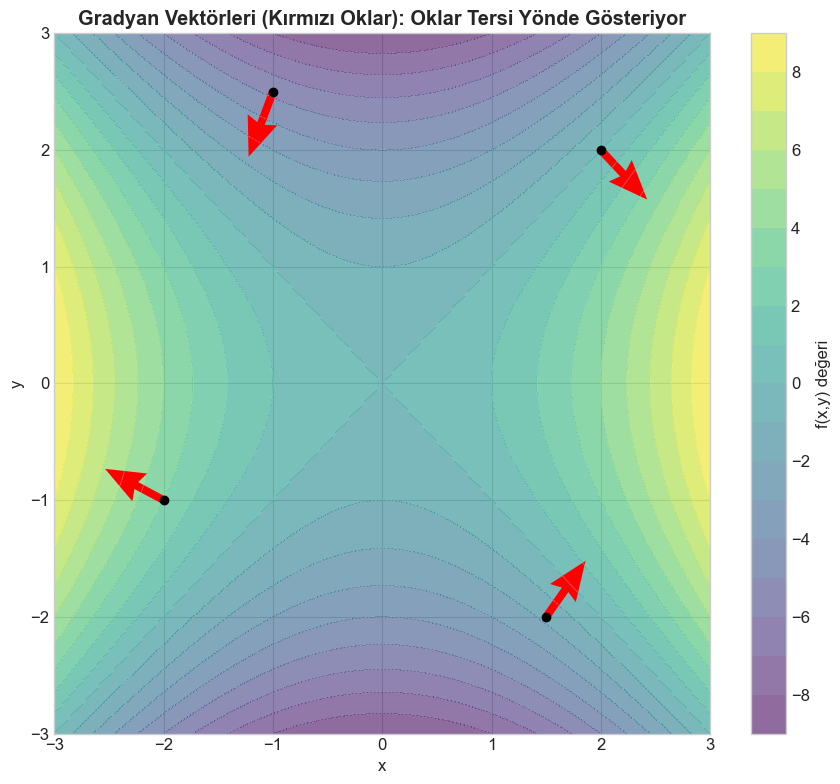

In [14]:
def f_yuzey(x, y):
    return x**2 - y**2

def gradyan_f(x, y):
    return np.array([2*x, -2*y])

x_grid = np.linspace(-3, 3, 100)
y_grid = np.linspace(-3, 3, 100)

X, Y = np.meshgrid(x_grid, y_grid) # meshgrid ile 2D grid olusturduk
Z = f_yuzey(X, Y)

test_noktalari = [(-2, -1), (1.5, -2), (2, 2), (-1, 2.5)]

fig, ax = plt.subplots(figsize=(9, 8))
kontur = ax.contourf(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
ax.contour(X, Y, Z, levels=20, colors='white', linewidths=0.5, alpha=0.4)
plt.colorbar(kontur, label='f(x,y) değeri')

for (px, py) in test_noktalari:
    grad = gradyan_f(px, py)
    grad_normalize = grad / np.linalg.norm(grad) * 0.6  # gorsellestirme icin sabit uzunluk
    ax.quiver(px, py, *grad_normalize, angles='xy', scale_units='xy', scale=1,
              color='red', width=0.012, headwidth=4)
    ax.plot(px, py, 'ko', markersize=6)

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Gradyan Vektörleri (Kırmızı Oklar): Oklar Tersi Yönde Gösteriyor', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [3Blue1Brown — Essence of Calculus](https://www.3blue1brown.com/topics/calculus) | Bölüm 1-3 | Bu notebook'un TEK EN ÖNEMLİ referansı |
| [MIT OCW — Calculus (Strang)](https://ocw.mit.edu/courses/res-18-001-calculus-online-textbook-spring-2005/) | Ch. 2 | Klasik, kapsamlı üniversite dersi |
| [Mathematics for Machine Learning](https://mml-book.github.io) | Ch. 5 | Türev/gradyan, ML bağlamında |
| [sympy Dokümantasyonu](https://docs.sympy.org/latest/tutorials/intro-tutorial/calculus.html) | Kütüphane | Bu notebook'ta kullanılan ana araç |
| [COVID-19 Data Repository (JHU CSSE)](https://github.com/CSSEGISandData/COVID-19) | Veri | time_series_covid_19_confirmed.csv kaynağı |